In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

In [ ]:
df_1 = pd.read_excel(r"vendor1.xlsx")
df_2 = pd.read_excel(r"vendor2.xlsx")
df_1.info(), df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  35 non-null     int64  
 1   YS           35 non-null     float64
 2   Mpa          35 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 972.0 bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  48 non-null     int64  
 1   YS           48 non-null     float64
 2   Mpa          48 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.3 KB


(None, None)

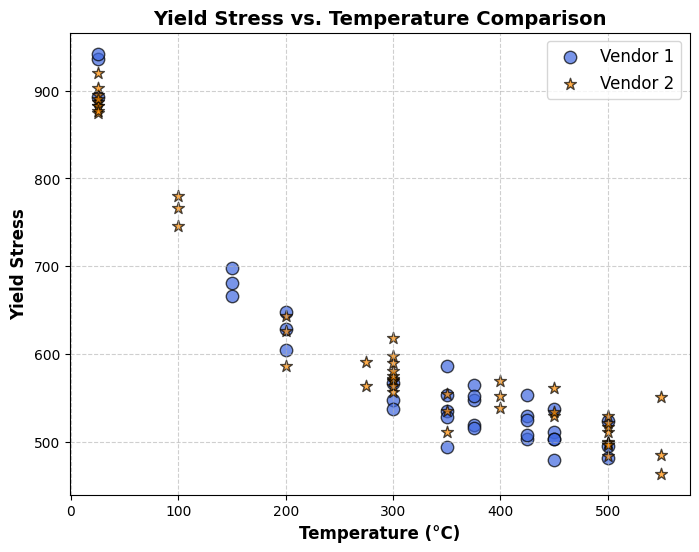

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(df_1["Temperature"], df_1["Mpa"], color='royalblue', edgecolors='black', alpha=0.7, s=80, label="Vendor 1")
plt.scatter(df_2["Temperature"], df_2["Mpa"], marker='*', color='darkorange', edgecolors='black', alpha=0.7, s=80, label="Vendor 2")

plt.xlabel("Temperature (°C)", fontsize=12, fontweight='bold')
plt.ylabel("Yield Stress", fontsize=12, fontweight='bold')
plt.title("Yield Stress vs. Temperature Comparison", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=12)

plt.show()

In [4]:
data = pd.concat([df_1, df_2], ignore_index=True)
data_sorted = data.sort_values(by="Temperature", ascending=True)
df_3 = data_sorted.reset_index(drop=True)
df_3.head(10)

,Temperature,YS,Mpa
0,25,1.04164,935.996871
1,25,1.04832,941.999386
2,25,0.99379,892.999818
3,25,0.97376,875.001261
4,25,0.98711,886.997304
5,25,0.98155,882.001199
6,25,0.99602,895.003652
7,25,0.99045,889.998561
8,25,1.00492,903.001014
9,25,1.02384,920.002147


In [5]:
df_dict = {temp: df_3[df_3["Temperature"] == temp].reset_index(drop=True) for temp in df_3["Temperature"].unique()}

df_dict[550]

,Temperature,YS,Mpa
0,550,0.61319,551.000270
1,550,0.51637,463.999755
2,550,0.53974,484.999569


In [6]:
# Ln(Power) Transform
data_sorted['Power_Transform'] = np.log(data_sorted['Temperature'])  # Ln(Power)

In [7]:
from scipy import optimize

In [8]:
# Predictor and response
X_values = data_sorted['Power_Transform'].values
Y_values = data_sorted['Mpa'].values

# Weibull regression log-likelihood
def weibull_regression_log_likelihood(params, x, y):
    shape = params[0]
    beta0 = params[1]
    beta1 = params[2]
    if shape <= 0:
        return np.inf
    scale = np.exp(beta0 + beta1 * x)
    return -np.sum(stats.weibull_min.logpdf(y, c=shape, scale=scale))

# Initial guess for [shape, β0, β1]
init_params = [2.0, np.log(np.mean(Y_values)), 0.0]
bounds = [(1e-6, None), (None, None), (None, None)]

result_regression = optimize.minimize(
    weibull_regression_log_likelihood,
    init_params,
    args=(X_values, Y_values),
    bounds=bounds,
    method='L-BFGS-B'
)

shape_reg, beta0_reg, beta1_reg = result_regression.x
print(f"[Regression Fit] Shape: {shape_reg:.4f}")

[Regression Fit] Shape: 22.7041


In [9]:
scale = np.exp(beta0_reg + beta1_reg * X_values)

In [10]:
X = X_values  # Predictor variable

Y = np.log(scale)
# Compute means
X_mean = sum(X) / len(X)
Y_mean = sum(Y) / len(Y)

# Compute slope
numerator = sum((X[i] - X_mean) * (Y[i] - Y_mean) for i in range(len(X)))
denominator = sum((X[i] - X_mean) ** 2 for i in range(len(X)))
w = numerator / denominator

# Compute intercept
u = Y_mean - w * X_mean

# Display results
print(f"Intercept (u): {u:.6f}")
print(f"Slope (w): {w:.6f}")

Intercept (u): 7.473187
Slope (w): -0.195017


In [11]:
u = u
m = shape_reg
w = w

print(f"Intercept (u): {u:.4f}")
print(f"Weibull Shape Parameter (m): {m:.4f}")
print(f"slope (w): {w:.4f}")

Intercept (u): 7.4732
Weibull Shape Parameter (m): 22.7041
slope (w): -0.1950


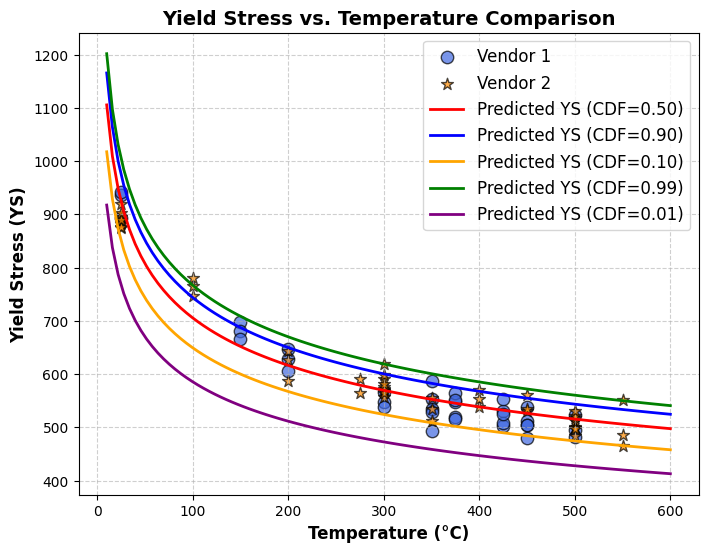

In [12]:
temperature_values = np.linspace(10, 600, 100)

# Assume mean shape for prediction
shape = m
intercept = u
slope = w
# cdf
cdf_50 = 0.5
cdf_90 = 0.9
cdf_10 = 0.1
cdf_99 = 0.99
cdf_01 = 0.01

ys_predicted_cdf_50 = np.exp(
    (intercept + (slope * np.log(temperature_values))) +
    ((1 / shape) * np.log(np.log(1 / (1 - cdf_50))))
)

ys_predicted_cdf_90 = np.exp(
    (intercept + (slope * np.log(temperature_values))) +
    ((1 / shape) * np.log(np.log(1 / (1 - cdf_90))))
)

ys_predicted_cdf_10 = np.exp(
    (intercept + (slope * np.log(temperature_values))) +
    ((1 / shape) * np.log(np.log(1 / (1 - cdf_10))))
)

ys_predicted_cdf_99 = np.exp(
    (intercept + (slope * np.log(temperature_values))) +
    ((1 / shape) * np.log(np.log(1 / (1 - cdf_99))))
)

ys_predicted_cdf_01 = np.exp(
    (intercept + (slope * np.log(temperature_values))) +
    ((1 / shape) * np.log(np.log(1 / (1 - cdf_01))))
)

plt.figure(figsize=(8, 6))

# Scatter plots
plt.scatter(df_1["Temperature"], df_1["Mpa"], color='royalblue', edgecolors='black', alpha=0.7, s=80, label="Vendor 1")
plt.scatter(df_2["Temperature"], df_2["Mpa"], marker='*', color='darkorange', edgecolors='black', alpha=0.7, s=80, label="Vendor 2")

# predicted YS curves
plt.plot(temperature_values, ys_predicted_cdf_50, color="red", linestyle="-", linewidth=2, label="Predicted YS (CDF=0.50)")
plt.plot(temperature_values, ys_predicted_cdf_90, color="blue", linestyle="-", linewidth=2, label="Predicted YS (CDF=0.90)")
plt.plot(temperature_values, ys_predicted_cdf_10, color="orange", linestyle="-", linewidth=2, label="Predicted YS (CDF=0.10)")
plt.plot(temperature_values, ys_predicted_cdf_99, color="green", linestyle="-", linewidth=2, label="Predicted YS (CDF=0.99)")
plt.plot(temperature_values, ys_predicted_cdf_01, color="purple", linestyle="-", linewidth=2, label="Predicted YS (CDF=0.01)")

plt.xlabel("Temperature (°C)", fontsize=12, fontweight="bold")
plt.ylabel("Yield Stress (YS)", fontsize=12, fontweight="bold")
plt.title("Yield Stress vs. Temperature Comparison", fontsize=14, fontweight="bold")

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.show()

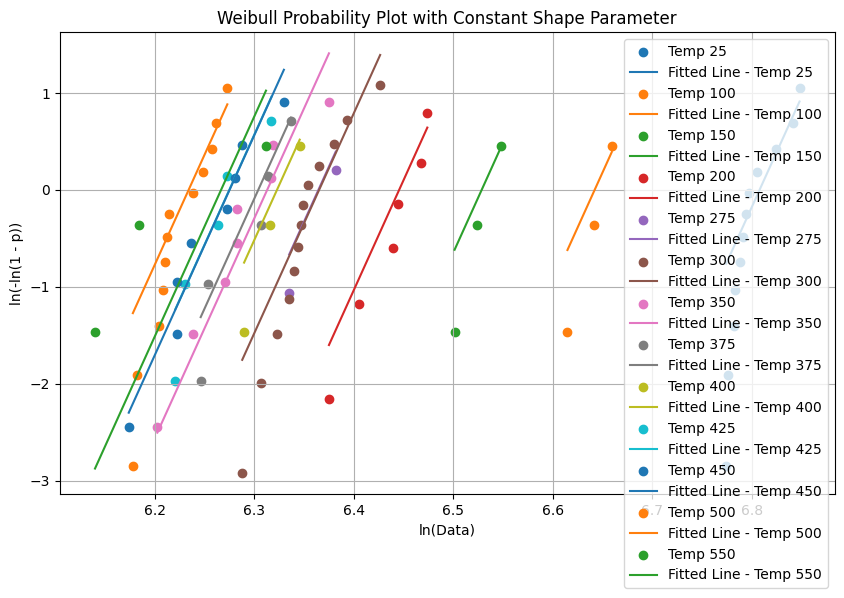

In [13]:
CONSTANT_SHAPE = m 

# Function to compute cumulative probability using Benard's median rank formula
def median_rank(n, i):
    return (i - 0.3) / (n + 0.4)

# Create Weibull probability plot for all temperature groups
plt.figure(figsize=(10, 6))

for temp in df_dict.keys():
    data = df_dict[temp]["Mpa"].values
    data = np.sort(data)  # Sort values

    # Compute cumulative probabilities using Benard’s formula
    n = len(data)
    p_values = np.array([median_rank(n, i + 1) for i in range(n)])

    # Apply Weibull probability plot transformation
    x_values = np.log(data)  # X-axis: ln(data)
    y_values = np.log(-np.log(1 - p_values))  # Y-axis: ln(-ln(1 - p))

    # Estimate Weibull scale parameter using MLE (keeping shape constant)
    _, loc, scale = stats.weibull_min.fit(data, floc=0, f0=CONSTANT_SHAPE)

    # Scatter plot for each temperature group
    plt.scatter(x_values, y_values, label=f"Temp {temp}")

    # Generate fitted Weibull line using constant shape parameter
    x_fit = np.linspace(min(data), max(data), 100)
    y_fit = np.log(-np.log(1 - stats.weibull_min.cdf(x_fit, CONSTANT_SHAPE, scale=scale)))
    plt.plot(np.log(x_fit), y_fit, linestyle='-', label=f"Fitted Line - Temp {temp}")

plt.title("Weibull Probability Plot with Constant Shape Parameter")
plt.xlabel("ln(Data)")
plt.ylabel("ln(-ln(1 - p))")
plt.legend()
plt.grid()
plt.show()